In [42]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

4037115


In [43]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [4]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [5]:
stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_4037115/2004208958.py:38: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_4037115/2004208958.py:39: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [6]:
def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

In [7]:
import numpy as np
import torch
from torch_geometric.data import Data

def build_graph_contact_sparse(noisy_contact_map, distance_map=None, sep_min=0):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')
    
    not_self = i != j
    pair_mask_full = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    contact_present = noisy_contact_map.bool()
    valid_edges = not_self & contact_present

    src, dst = torch.nonzero(valid_edges, as_tuple=True)

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[src, dst].unsqueeze(-1)

    if distance_map is not None:
        known = torch.as_tensor(np.isfinite(distance_map), dtype=torch.bool)
        true_contact_map = torch.as_tensor(
            contact_from_distance(distance_map, threshold=8.0),
            dtype=torch.float
        )
        labels_full = (known & (true_contact_map == 1)).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels_full = torch.zeros((N, N), dtype=torch.float)

    edge_mask_full = known & long_range_ok

    edge_mask = edge_mask_full[src, dst]       
    pair_mask = pair_mask_full[src, dst]        
    y = labels_full[src, dst].unsqueeze(-1)

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        edge_mask=edge_mask,
        pair_mask=pair_mask,
        L=N
    )

In [ ]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB

folder_path = "PDB"
p_detect_by_r = total_percentage

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)

        L= distance_map.shape[0]
        K = 5 * L
        noisy_contact_map, __ = sample_noisy_contact_map_from_distance(distance_map,p_detect_by_r,K,threshold=8.0,seed=1)
        data = build_graph_contact_sparse(noisy_contact_map, distance_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")


torch.save(all_data, "all_data_likeDCA_sparse.pt")

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00006.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb


In [8]:
all_data = torch.load("all_data_likeDCA_sparse.pt",weights_only=False)   
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [9]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out
    



from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [10]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [11]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=30, mlp_hidden_ch=15, GNN_layers=4).to(device)

save_path = "best_model_cc_likeDCA_sparse.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=5,min_lr=1e-6)


train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

for epoch in range(3000):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

pos_weight: 0.9774932265281677
Epoch 0: Train Loss=0.6618, Val Loss=0.6191
Epoch 1: Train Loss=0.5695, Val Loss=0.5228
Epoch 2: Train Loss=0.4986, Val Loss=0.4754
Epoch 3: Train Loss=0.4662, Val Loss=0.4531
Epoch 4: Train Loss=0.4509, Val Loss=0.4424
Epoch 5: Train Loss=0.4427, Val Loss=0.4357
Epoch 6: Train Loss=0.4370, Val Loss=0.4310
Epoch 7: Train Loss=0.4324, Val Loss=0.4279
Epoch 8: Train Loss=0.4289, Val Loss=0.4241
Epoch 9: Train Loss=0.4257, Val Loss=0.4210
Epoch 10: Train Loss=0.4231, Val Loss=0.4184
Epoch 11: Train Loss=0.4205, Val Loss=0.4156
Epoch 12: Train Loss=0.4177, Val Loss=0.4137
Epoch 13: Train Loss=0.4154, Val Loss=0.4124
Epoch 14: Train Loss=0.4135, Val Loss=0.4101
Epoch 15: Train Loss=0.4116, Val Loss=0.4082
Epoch 16: Train Loss=0.4099, Val Loss=0.4067
Epoch 17: Train Loss=0.4085, Val Loss=0.4053
Epoch 18: Train Loss=0.4075, Val Loss=0.4042
Epoch 19: Train Loss=0.4060, Val Loss=0.4028
Epoch 20: Train Loss=0.4045, Val Loss=0.4015
Epoch 21: Train Loss=0.4036, Val L

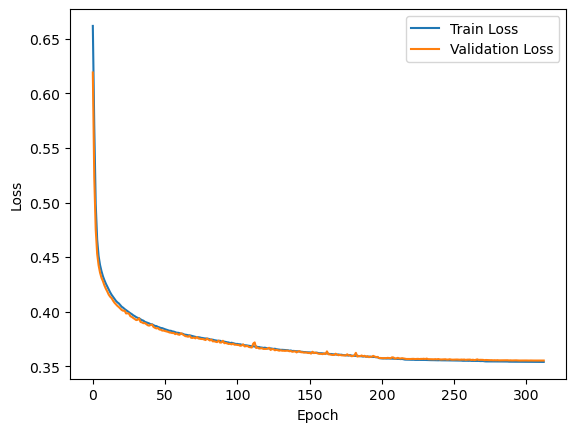

In [45]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show() 

In [46]:
save_path = "best_model_cc_likeDCA_sparse.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

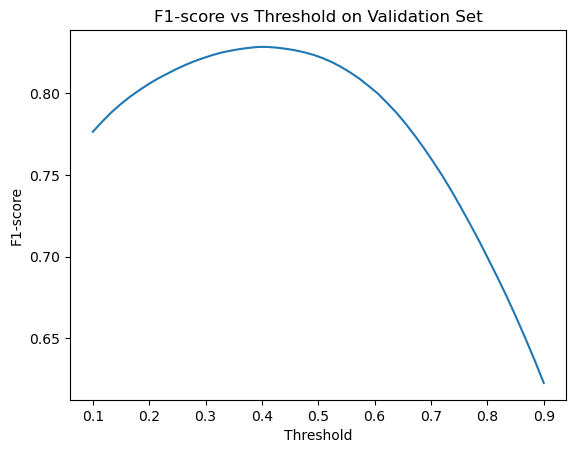

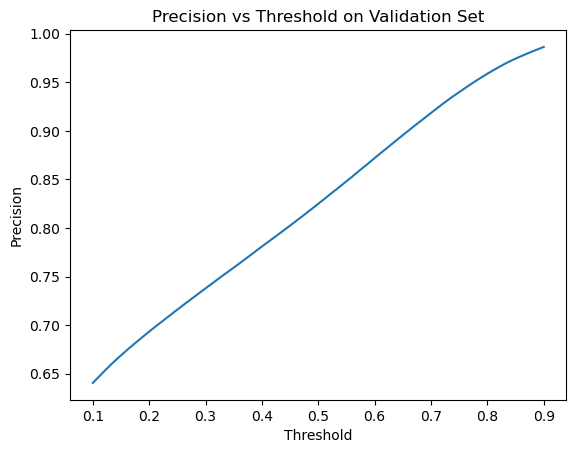

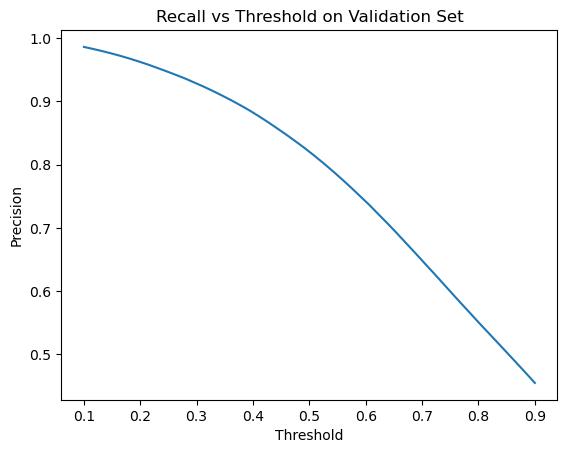

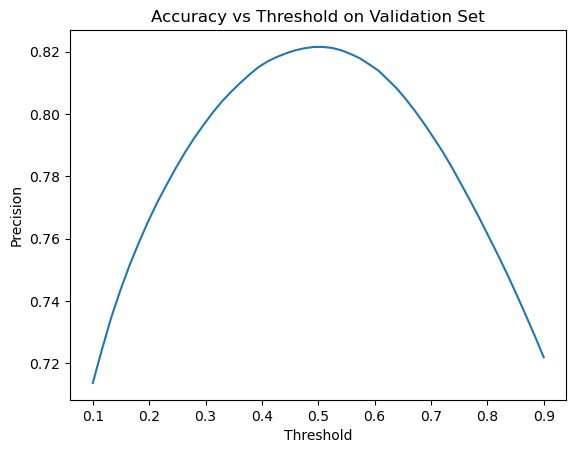

Best threshold: 0.5082 with F1-score: 0.8285 and accuracy: 0.8215


In [67]:
#validation to decide the threshold


def collect_val_predictions(model, loader, device):
    model.eval()

    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, logits = model(batch)

            logits = logits.squeeze(-1)
            labels = batch.y.squeeze(-1)
            mask = batch.edge_mask

            scores = torch.sigmoid(logits)

            all_scores.append(scores[mask].cpu())
            all_labels.append(labels[mask].cpu())

    return torch.cat(all_scores), torch.cat(all_labels)

scores, labels = collect_val_predictions(model, test_loader, device)


thresholds = np.linspace(0.1, 0.9, 50)
best_thresh = 0.5
best_f1 = 0.0
best_accuracy=0.0
f1_tot=[]
precision_tot=[]
recall_tot=[]
accuracy_tot=[]
for t in thresholds:
    preds = (scores >= t).float()

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()
    tn = ((preds == 0) & (labels == 0)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    accuracy=(tp+tn)/(tp+fp+fn+tn)
    accuracy_tot.append(accuracy)


    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    precision_tot.append(precision)
    recall_tot.append(recall)
    f1_tot.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        #best_thresh = t

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_thresh = t


plt.plot(thresholds, f1_tot)
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold on Validation Set")
plt.show()

plt.plot(thresholds, precision_tot)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold on Validation Set")
plt.show()

plt.plot(thresholds, recall_tot)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Recall vs Threshold on Validation Set")
plt.show()

plt.plot(thresholds, accuracy_tot)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Accuracy vs Threshold on Validation Set")
plt.show()

print(f"Best threshold: {best_thresh:.4f} with F1-score: {best_f1:.4f} and accuracy: {best_accuracy:.4f}")



PR AUC (sklearn auc): 0.9231
Average Precision (sklearn): 0.9231
Validation ROC AUC GNN: 0.9150969731345017


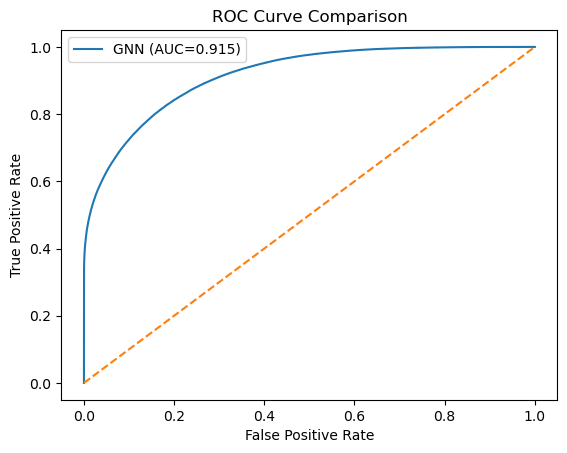

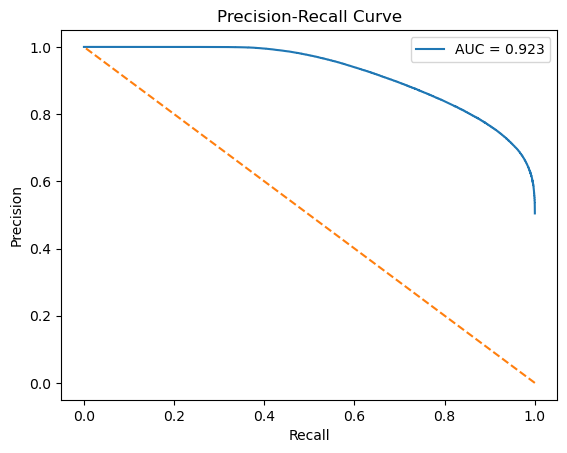

Precision @ 0.5081632653061224: 0.8289
Recall @ 0.5081632653061224: 0.8148
F1 @ 0.5081632653061224: 0.8218


In [68]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, auc, average_precision_score, roc_curve


threshold=best_thresh  

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

# Concatenate all batches
all_probs = torch.cat(all_probs).numpy()
all_true = torch.cat(all_true).numpy()


precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(all_true, all_probs)

print(f"PR AUC (sklearn auc): {pr_auc:.4f}")
print(f"Average Precision (sklearn): {avg_precision:.4f}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()





plt.figure()
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle="--") 
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


from sklearn.metrics import precision_score, recall_score, f1_score

pred_contacts = (all_probs >= threshold).astype(int)

precision_val = precision_score(all_true, pred_contacts, zero_division=0)
recall_val = recall_score(all_true, pred_contacts, zero_division=0)
f1_val = f1_score(all_true, pred_contacts, zero_division=0)

print(f"Precision @ {threshold}: {precision_val:.4f}")
print(f"Recall @ {threshold}: {recall_val:.4f}")
print(f"F1 @ {threshold}: {f1_val:.4f}")

Precision: 0.8428006701931212


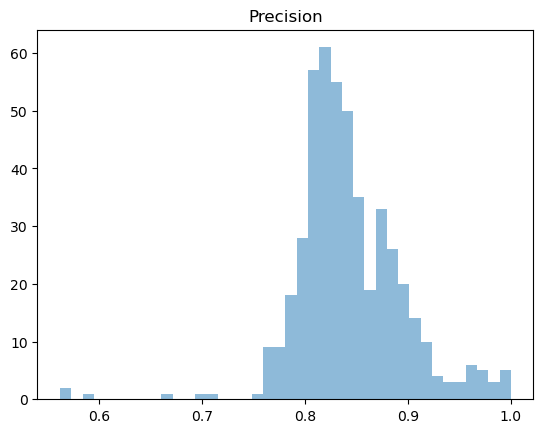

In [69]:
#precision per graph


def precision_graph(model, loader, device, treshold):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                pred_contacts = (probs_g >= threshold).int().cpu().numpy()
                true_g = true_g.cpu().numpy()

                precision_g = precision_score(true_g, pred_contacts, zero_division=0)

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Precision:", precision_graph(model, test_loader, device, treshold=best_thresh)[0])



plt.hist(precision_graph(model, test_loader, device, treshold=best_thresh)[1], bins=40, alpha=0.5)
plt.title("Precision")
plt.show()


In [70]:
precision= precision_graph(model, test_loader, device, treshold=best_thresh)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.8356374807987711, 0.8050314465408805, 0.8479467258601554, 0.7785977859778598, 0.8886827458256029, 0.823960880195599, 0.9058577405857741, 0.8291215403128761, 0.8262195121951219, 0.8114169215086646, 0.8782608695652174, 0.8603174603174604, 0.7664418212478921, 0.7968397291196389, 1.0, 0.868421052631579, 0.8696808510638298, 0.8350515463917526, 0.8014112903225806, 0.8370901639344263, 0.9223300970873787, 0.8053302433371958, 0.7664418212478921, 0.8333333333333334, 0.9, 0.7974816369359916, 0.8283671036948749, 0.8597560975609756, 0.8294871794871795, 0.82996632996633, 0.8032178217821783, 0.8995433789954338, 0.8717672413793104, 0.92, 0.804953560371517, 0.8760869565217392, 0.7895167895167895, 0.8786472148541115, 0.7892518440463646, 0.8338815789473685, 0.9283819628647215, 0.8121546961325967, 0.8289738430583501, 0.9125364431486881, 0.8596491228070176, 0.8212435233160622, 0.8983833718244804, 0.8409506398537477, 0.7942073170731707, 0.9168646080760094, 0.8478605388272583, 0.8211764705882353, 0.786740

In [72]:
import torch
import matplotlib.pyplot as plt

def graph_to_matrix(data, values, symmetric=True):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes), dtype=values.dtype)

    edge_index = data.edge_index
    values = values.squeeze()

    src, dst = edge_index
    mat[src, dst] = values

    if symmetric:
        mat[dst, src] = values

    return mat


def plot_contact_map_with_confusion(data, scores, threshold=0.5, background="noisy"):
    """
    data: PyG Data object
    scores: predicted probabilities for each edge (shape [num_edges] or [num_edges, 1])
    threshold: threshold on scores to get binary prediction
    background: "noisy" or "true"
    """
    # Reconstruct sparse edge-level values
    scores = scores.squeeze().detach().cpu()
    y = data.y.squeeze().detach().cpu()
    edge_mask = data.edge_mask.bool().detach().cpu() if hasattr(data, "edge_mask") else torch.ones_like(y, dtype=torch.bool)

    pred = (scores >= threshold).float()

    # Keep only edges you care about (same logic as training)
    src = data.edge_index[0].detach().cpu()
    dst = data.edge_index[1].detach().cpu()

    # Optional: use only masked edges for evaluation
    src = src[edge_mask]
    dst = dst[edge_mask]
    y = y[edge_mask]
    pred = pred[edge_mask]

    # Category masks
    tp = (pred == 1) & (y == 1)
    fp = (pred == 1) & (y == 0)
    fn = (pred == 0) & (y == 1)
    tn = (pred == 0) & (y == 0)

    # Background matrix
    if background == "noisy":  ####in the background only the contact present in the input "noisy PDB" are present
        bg = graph_to_matrix(data, data.edge_attr.cpu(), symmetric=True)
    elif background == "true": 
        bg = graph_to_matrix(data, data.y.cpu(), symmetric=True)
    else:
        bg = torch.zeros((data.x.shape[0], data.x.shape[0]))

    bg = bg.numpy()

    plt.figure(figsize=(7, 7))
    plt.imshow(bg, origin="lower", cmap="Greys", interpolation="nearest")

    # Plot categories
    plt.scatter(dst[tp], src[tp], c="green", s=20, label="TP", edgecolors="none")
    plt.scatter(dst[fp], src[fp], c="red", s=20, label="FP", edgecolors="none")
    plt.scatter(dst[fn], src[fn], c="blue", s=20, label="FN", edgecolors="none")
    plt.scatter(dst[tn], src[tn], c="gray", s=8, alpha=0.25, label="TN", edgecolors="none")

    plt.xlabel("j")
    plt.ylabel("i")
    plt.title(f"Contact map confusion overlay (threshold={threshold:.2f})")
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

Data(x=[440, 16], edge_index=[2, 4400], edge_attr=[4400, 1], y=[4400, 1], edge_mask=[4400], pair_mask=[4400], L=440)


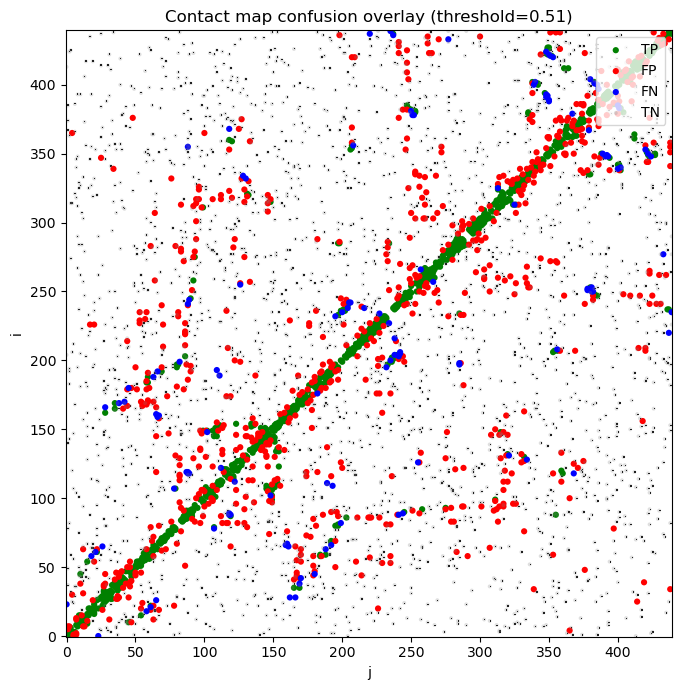

In [73]:
pos=142
#worst case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))


plot_contact_map_with_confusion(batch.cpu(),scores.cpu(),threshold=best_thresh,background="noisy")

In [74]:
###test on DCA-like data

folder_path = "Data"

dca_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']


        k = 5*len(sequence)  
        binary_map = top_k_mask(contact_map_DCA, k)
        
        data = build_graph_contact_sparse(binary_map, distance_map)
        
        dca_data.append(data)

test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

PR AUC (sklearn auc): 0.8842
Average Precision (sklearn): 0.8842
Validation ROC AUC GNN: 0.8117314080564306


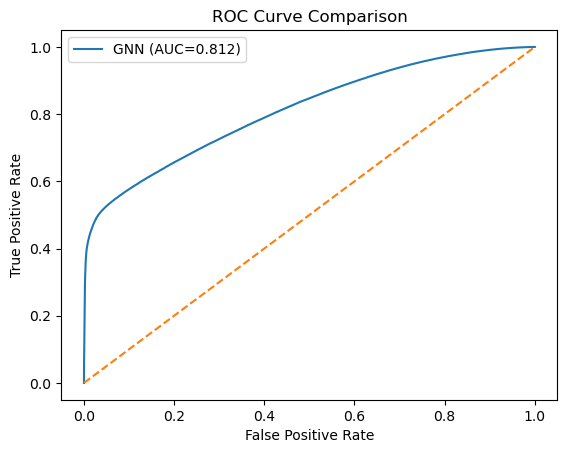

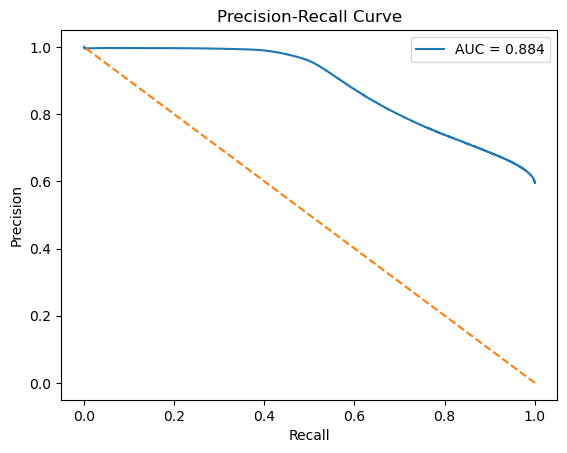

Precision @ 0.5081632653061224: 0.7201
Recall @ 0.5081632653061224: 0.8355
F1 @ 0.5081632653061224: 0.7735
Accuracy @ 0.5081632653061224: 0.7087
Precision DCA: 0.5953
Recall DCA: 1.0000
F1 DCA: 0.7463
Accuracy DCA: 0.5953


In [76]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, auc, average_precision_score, roc_curve


threshold=best_thresh 

model.eval()

all_probs = []
all_true = []
all_contact_dca=[]
for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    dca_contacts = batch.edge_attr.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    all_probs.append(probs[mask].cpu())
    all_contact_dca.append(dca_contacts[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

# Concatenate all batches
all_probs = torch.cat(all_probs).numpy()
all_true = torch.cat(all_true).numpy()
all_contact_dca = torch.cat(all_contact_dca).numpy()


precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(all_true, all_probs)

print(f"PR AUC (sklearn auc): {pr_auc:.4f}")
print(f"Average Precision (sklearn): {avg_precision:.4f}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


plt.figure()
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle="--") 
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score

pred_contacts = (all_probs >= threshold).astype(int)

precision_val = precision_score(all_true, pred_contacts, zero_division=0)
recall_val = recall_score(all_true, pred_contacts, zero_division=0)
f1_val = f1_score(all_true, pred_contacts, zero_division=0)
acc_val= accuracy_score(all_true, pred_contacts)

print(f"Precision @ {threshold}: {precision_val:.4f}")
print(f"Recall @ {threshold}: {recall_val:.4f}")
print(f"F1 @ {threshold}: {f1_val:.4f}")
print(f"Accuracy @ {threshold}: {acc_val:.4f}")

precision_val_dca = precision_score(all_true, all_contact_dca, zero_division=0)
recall_val_dca = recall_score(all_true, all_contact_dca, zero_division=0)
f1_val_dca = f1_score(all_true, all_contact_dca, zero_division=0)
acc_val_dca= accuracy_score(all_true, all_contact_dca)
print(f"Precision DCA: {precision_val_dca:.4f}")
print(f"Recall DCA: {recall_val_dca:.4f}")   ##always 1 since there are not false negative? (there are not negative since we are looking only at the contact that are positive in the dca)  recall=tp/(tp+fn)
print(f"F1 DCA: {f1_val_dca:.4f}")
print(f"Accuracy DCA: {acc_val_dca:.4f}")

Precision: 0.7151978802040585


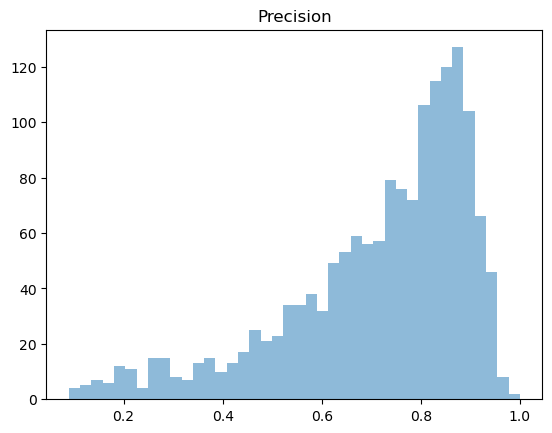

In [77]:
print("Precision:", precision_graph(model, test_dca_loader, device, treshold=best_thresh)[0])

plt.hist(precision_graph(model, test_dca_loader, device, treshold=best_thresh)[1], bins=40, alpha=0.5)
plt.title("Precision")
plt.show()


In [78]:
precision= precision_graph(model, test_dca_loader, device, treshold=best_thresh)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.6486486486486487, 0.8991596638655462, 0.8368200836820083, 0.9220338983050848, 0.7492877492877493, 0.6, 0.6374269005847953, 0.851123595505618, 0.9137931034482759, 0.7396694214876033, 0.959493670886076, 0.7851662404092071, 0.8849840255591054, 0.9377049180327869, 0.47058823529411764, 0.8463687150837989, 0.9050160085378869, 0.9263932702418507, 0.7516778523489933, 0.8401360544217688, 0.9391124871001032, 0.7791798107255521, 0.7911227154046997, 0.7631578947368421, 0.7439024390243902, 0.8363095238095238, 0.6953488372093023, 0.8768577494692145, 0.6826347305389222, 0.1561712846347607, 0.720626631853786, 0.5131964809384164, 0.7330316742081447, 0.8807588075880759, 0.7021276595744681, 0.9516129032258065, 0.8989473684210526, 0.5158371040723982, 0.8097826086956522, 0.7705192629815746, 0.5895522388059702, 0.8484320557491289, 0.8321013727560718, 0.8140138408304498, 0.7693761814744802, 0.8575418994413407, 0.8257575757575758, 0.8669354838709677, 0.942627653471027, 0.8795454545454545, 0.896428571428571

Data(x=[653, 16], edge_index=[2, 6530], edge_attr=[6530, 1], y=[6530, 1], edge_mask=[6530], pair_mask=[6530], L=653)


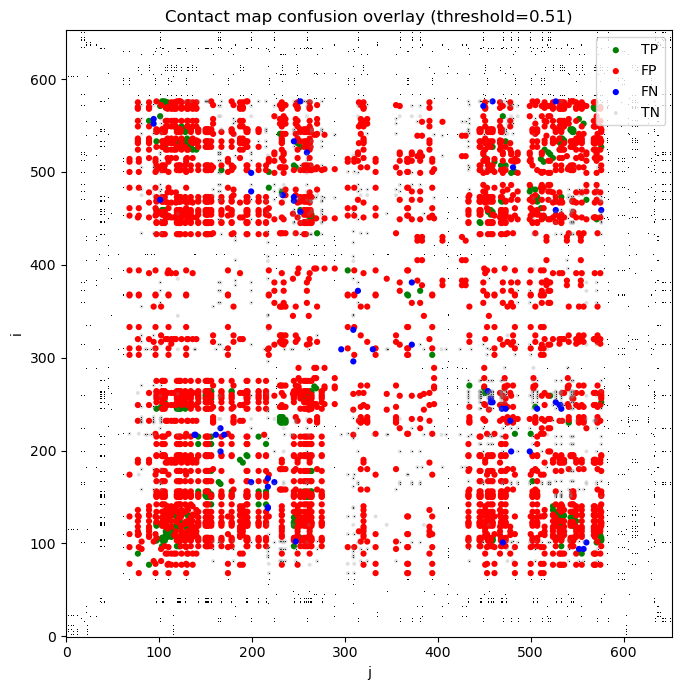

In [79]:
pos=1147
#worst case

i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))


plot_contact_map_with_confusion(batch.cpu(),scores.cpu(),threshold=best_thresh,background="noisy")